### Часть 1
Решить задачу классификации пассажиров Титаника.
Набор данных можно скачать здесь: https://www.kaggle.com/c/titanic/data?select=train.csv
Для обучения использовать файл train.csv, для тестирования test.csv

Для предобработки данных и обучения модели использовать pipeline из Scikit-learn

2) Проверьте наличие пропущенных значений и проанализируйте, в каких переменных они присутствуют.

3) Проведите анализ выживаемости по полу, возрасту, классу билета и другим факторам, которые кажутся интересными.

4) Разделите данные на признаки и целевую переменную, а затем на обучающую и тестовую выборки (80% на 20%).

5) Постройте модель дерева решений (DecisionTreeClassifier) для предсказания выживаемости пассажиров на основе признаков: пол, возраст, стоимость билета.

6) Оцените модель с помощью метрик: accuracy, precision, recall, F1-score. Постройте матрицу ошибок.

#### 2. Проверьте наличие пропущенных значений и проанализируйте, в каких переменных они присутствуют.

In [2]:
import pandas as pd

df = pd.read_csv('train.csv')

print("Пропущенные значения:")
print(df.isnull().sum())

print("\nСтолбцы с пропусками:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Пропущенные значения:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Столбцы с пропусками:
Age         177
Cabin       687
Embarked      2
dtype: int64


#### 3. Проведите анализ выживаемости по полу, возрасту, классу билета и другим факторам, которые кажутся интересными.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
print("=== ВЫЖИВАЕМОСТЬ ПО ПОЛУ ===")
print(pd.crosstab(df['Sex'], df['Survived'], margins=True))

print("\nПроцент выживших:")
print(df.groupby('Sex')['Survived'].mean() * 100)
print("\n" + "="*50 + "\n")

=== ВЫЖИВАЕМОСТЬ ПО ПОЛУ ===
Survived    0    1  All
Sex                    
female     81  233  314
male      468  109  577
All       549  342  891

Процент выживших:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64




In [7]:
print("=== ВЫЖИВАЕМОСТЬ ПО КЛАССУ ===")
print(pd.crosstab(df['Pclass'], df['Survived'], margins=True))

print("\nПроцент выживших:")
print(df.groupby('Pclass')['Survived'].mean() * 100)
print("\n" + "="*50 + "\n")

=== ВЫЖИВАЕМОСТЬ ПО КЛАССУ ===
Survived    0    1  All
Pclass                 
1          80  136  216
2          97   87  184
3         372  119  491
All       549  342  891

Процент выживших:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64




In [9]:
print("=== ВЫЖИВАЕМОСТЬ ПО ВОЗРАСТНЫМ ГРУППАМ ===")
bins = [0, 12, 18, 35, 60, 100]
labels = ['Дети (0-12)', 'Подростки (13-18)', 'Взрослые (19-35)', 'Средний возраст (36-60)', 'Пожилые (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(pd.crosstab(df['AgeGroup'], df['Survived']))
print("\nПроцент выживших по группам:")
print(df.groupby('AgeGroup')['Survived'].mean() * 100)
print("\n" + "="*50 + "\n")

=== ВЫЖИВАЕМОСТЬ ПО ВОЗРАСТНЫМ ГРУППАМ ===
Survived                   0    1
AgeGroup                         
Дети (0-12)               29   40
Подростки (13-18)         40   30
Взрослые (19-35)         221  137
Средний возраст (36-60)  117   78
Пожилые (60+)             17    5

Процент выживших по группам:
AgeGroup
Дети (0-12)                57.971014
Подростки (13-18)          42.857143
Взрослые (19-35)           38.268156
Средний возраст (36-60)    40.000000
Пожилые (60+)              22.727273
Name: Survived, dtype: float64




In [13]:
print("=== ВЫЖИВАЕМОСТЬ: ПОЛ + КЛАСС БИЛЕТА ===")
pivot_table = pd.crosstab([df['Sex'], df['Pclass']], df['Survived'], margins=True)
print(pivot_table)
print("\nПроцент выживших:")
print(df.groupby(['Sex', 'Pclass'])['Survived'].mean() * 100)

=== ВЫЖИВАЕМОСТЬ: ПОЛ + КЛАСС БИЛЕТА ===
Survived         0    1  All
Sex    Pclass               
female 1         3   91   94
       2         6   70   76
       3        72   72  144
male   1        77   45  122
       2        91   17  108
       3       300   47  347
All            549  342  891

Процент выживших:
Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64


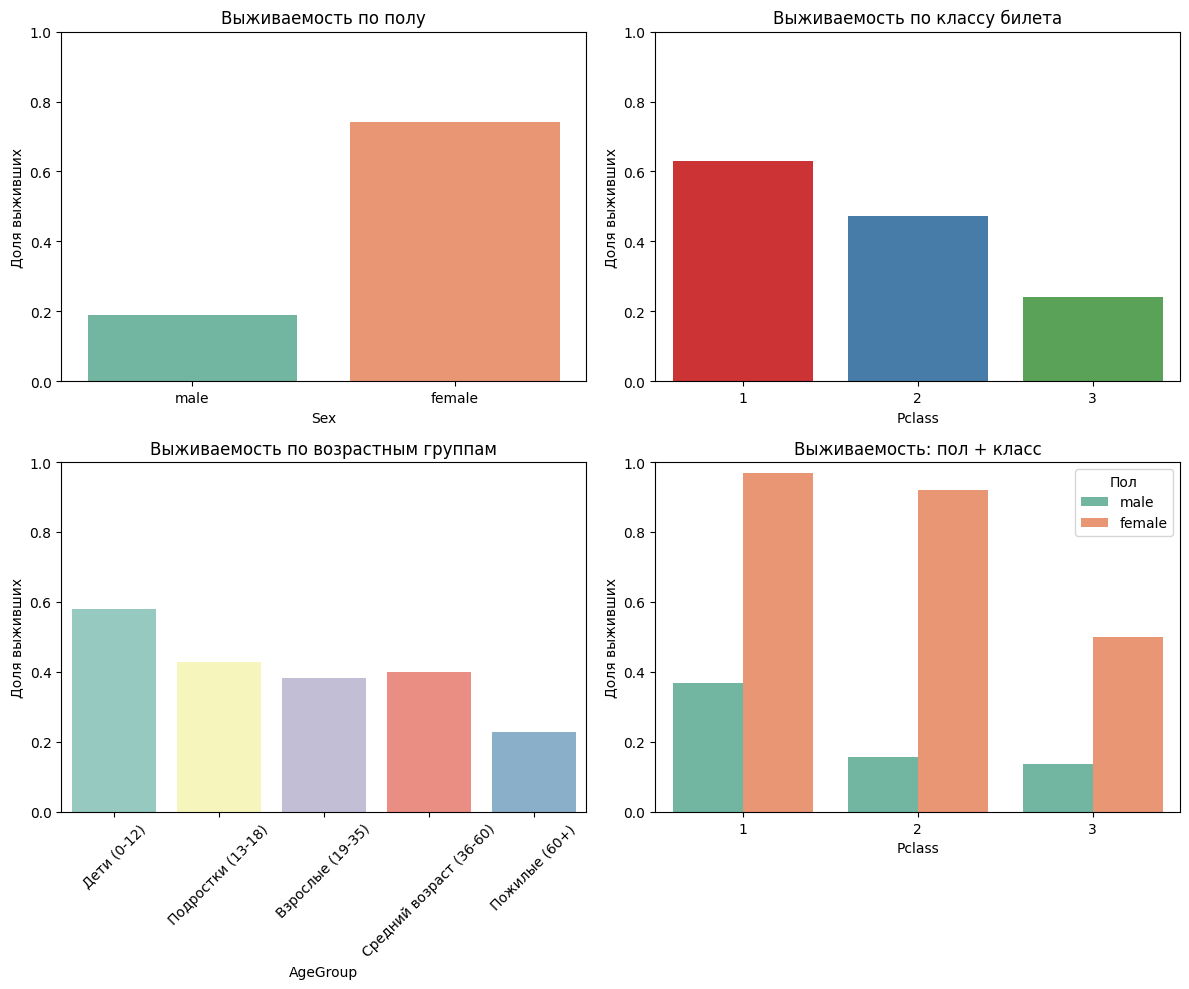

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.barplot(x='Sex', y='Survived', data=df, errorbar=None, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Выживаемость по полу')
axes[0,0].set_ylabel('Доля выживших')
axes[0,0].set_ylim(0,1)

sns.barplot(x='Pclass', y='Survived', data=df, errorbar=None, palette='Set1', ax=axes[0,1])
axes[0,1].set_title('Выживаемость по классу билета')
axes[0,1].set_ylabel('Доля выживших')
axes[0,1].set_ylim(0,1)

sns.barplot(x='AgeGroup', y='Survived', data=df, errorbar=None, palette='Set3', ax=axes[1,0])
axes[1,0].set_title('Выживаемость по возрастным группам')
axes[1,0].set_ylabel('Доля выживших')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylim(0,1)

sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, errorbar=None, palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Выживаемость: пол + класс')
axes[1,1].set_ylabel('Доля выживших')
axes[1,1].set_ylim(0,1)
axes[1,1].legend(title='Пол')

plt.tight_layout()
plt.show()

#### 4. Разделите данные на признаки и целевую переменную, а затем на обучающую и тестовую выборки (80% на 20%).

In [15]:
from sklearn.model_selection import train_test_split

X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = df['Survived']

X = pd.get_dummies(X, columns=['Sex'], drop_first=True)

X = X.dropna()
y = y[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (571, 6)
Размер тестовой выборки: (143, 6)


#### 5. Постройте модель дерева решений (DecisionTreeClassifier) для предсказания выживаемости пассажиров на основе признаков: пол, возраст, стоимость билета.

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

features = ['Sex', 'Age', 'Fare']
X = df[features]
y = df['Survived']

X = pd.get_dummies(X, columns=['Sex'], drop_first=True)

X = X.dropna()
y = y[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = DecisionTreeClassifier(random_state=42, max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("=== МОДЕЛЬ ДЕРЕВА РЕШЕНИЙ ===")
print(f"Точность (accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nДетальный отчет:")
print(classification_report(y_test, y_pred, target_names=['Погиб', 'Выжил']))

print("\nВажность признаков:")
print(f"Пол (мужской): {model.feature_importances_[0]:.3f}")
print(f"Возраст: {model.feature_importances_[1]:.3f}")
print(f"Стоимость билета: {model.feature_importances_[2]:.3f}")

=== МОДЕЛЬ ДЕРЕВА РЕШЕНИЙ ===
Точность (accuracy): 0.77

Детальный отчет:
              precision    recall  f1-score   support

       Погиб       0.78      0.86      0.82        85
       Выжил       0.76      0.64      0.69        58

    accuracy                           0.77       143
   macro avg       0.77      0.75      0.75       143
weighted avg       0.77      0.77      0.77       143


Важность признаков:
Пол (мужской): 0.140
Возраст: 0.266
Стоимость билета: 0.595


#### 6. Оцените модель с помощью метрик: accuracy, precision, recall, F1-score. Постройте матрицу ошибок.

=== МЕТРИКИ МОДЕЛИ ===
Accuracy (точность): 0.769
Precision (точность предсказания 1): 0.755
Recall (полнота): 0.638
F1-score: 0.692


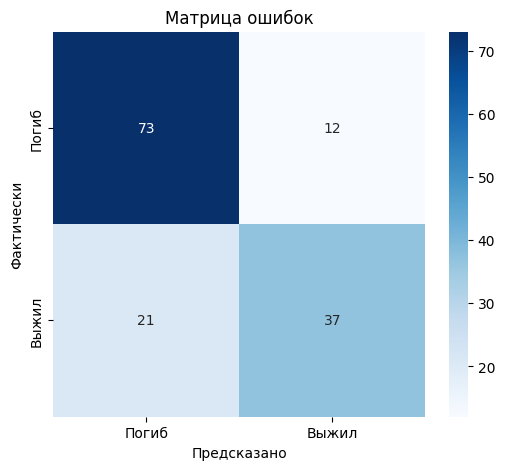


Расшифровка матрицы ошибок:
True Negative (верно погиб): 73
False Positive (ложно выжил): 12
False Negative (ложно погиб): 21
True Positive (верно выжил): 37


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== МЕТРИКИ МОДЕЛИ ===")
print(f"Accuracy (точность): {accuracy:.3f}")
print(f"Precision (точность предсказания 1): {precision:.3f}")
print(f"Recall (полнота): {recall:.3f}")
print(f"F1-score: {f1:.3f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Погиб', 'Выжил'], 
            yticklabels=['Погиб', 'Выжил'])
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.title('Матрица ошибок')
plt.show()

print("\nРасшифровка матрицы ошибок:")
print(f"True Negative (верно погиб): {cm[0,0]}")
print(f"False Positive (ложно выжил): {cm[0,1]}")
print(f"False Negative (ложно погиб): {cm[1,0]}")
print(f"True Positive (верно выжил): {cm[1,1]}")

### Часть 2
Используя данные и модель дерева решений из предыдущего задания (Титаник), выполните следующие шаги:

1. Построение графиков: Создайте несколько графиков, которые визуализируют основные характеристики датасета.

2. Диаграмма рассеяния: Постройте диаграмму рассеяния (scatter plot) для визуализации зависимости переменных.

3. Столбчатая диаграмма: Постройте столбчатую диаграмму для сравнения выживаемости пассажиров в зависимости от пола или класса билета.

4. Боксплоты: Постройте boxplot (диаграмму размаха) для анализа распределения возраста пассажиров в зависимости от их выживаемости.

5. Круговая диаграмма: Постройте круговую диаграмму для визуализации распределения пассажиров по полу или классу.

6. Дерево решений: На основе модели дерева решений, которую вы построили в предыдущем задании, визуализируйте структуру дерева. Опишите, какие выводы можно сделать на основе полученного дерева решений.

#### 1. Построение графиков: Создайте несколько графиков, которые визуализируют основные характеристики датасета.

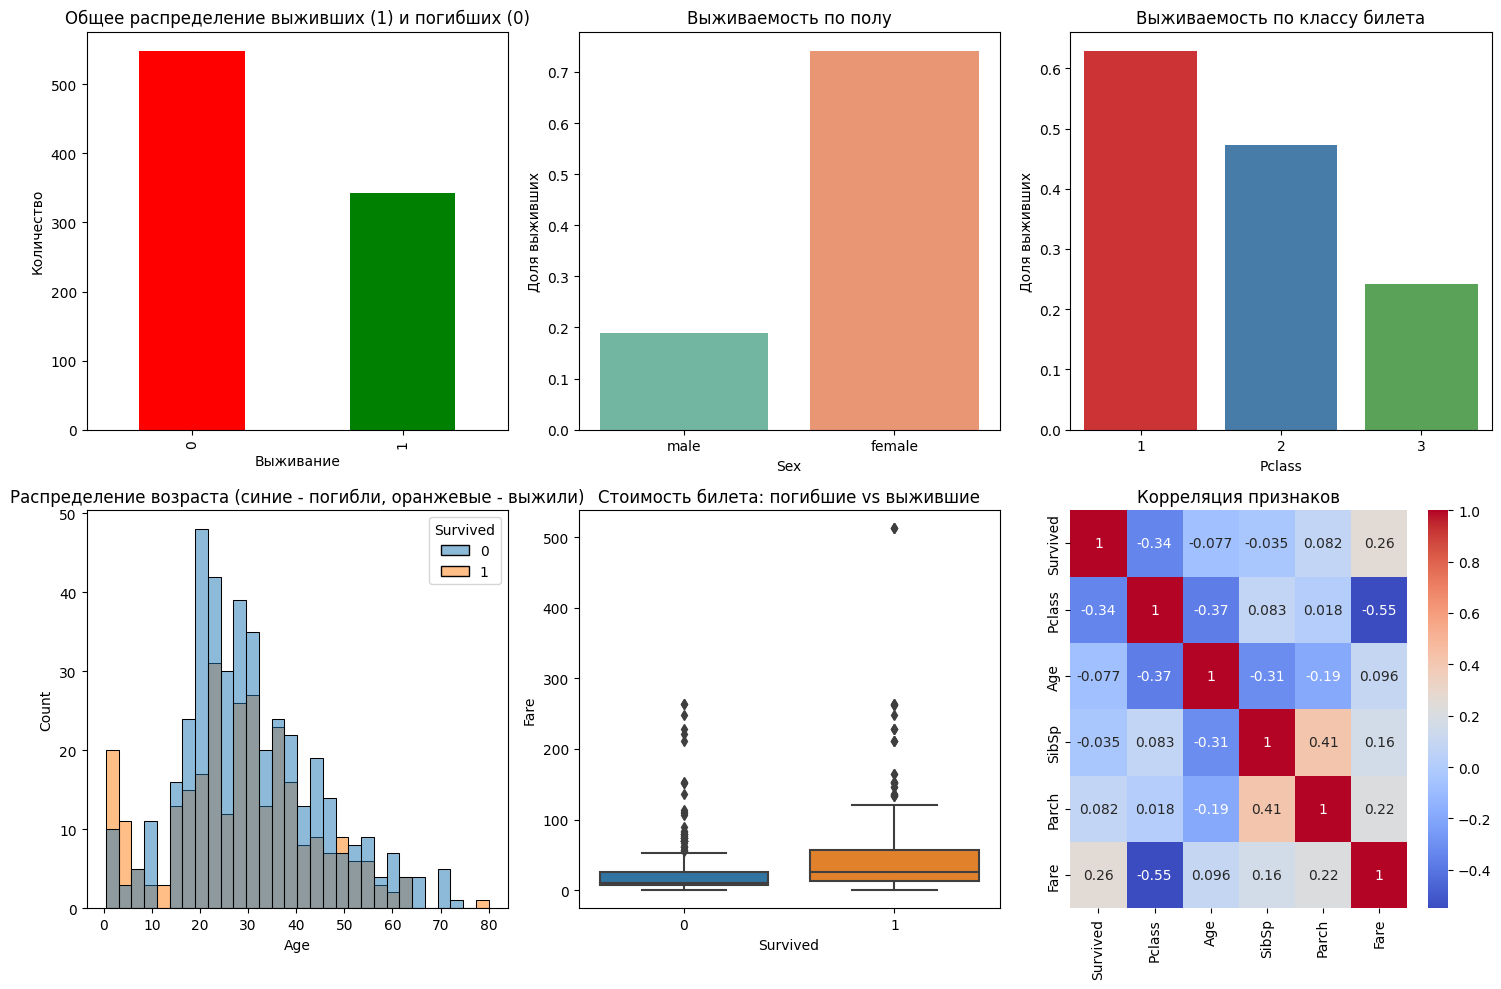

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

df['Survived'].value_counts().plot(kind='bar', ax=axes[0,0], color=['red', 'green'])
axes[0,0].set_title('Общее распределение выживших (1) и погибших (0)')
axes[0,0].set_xlabel('Выживание')
axes[0,0].set_ylabel('Количество')

sns.barplot(x='Sex', y='Survived', data=df, errorbar=None, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Выживаемость по полу')
axes[0,1].set_ylabel('Доля выживших')

sns.barplot(x='Pclass', y='Survived', data=df, errorbar=None, ax=axes[0,2], palette='Set1')
axes[0,2].set_title('Выживаемость по классу билета')
axes[0,2].set_ylabel('Доля выживших')

sns.histplot(data=df, x='Age', hue='Survived', bins=30, alpha=0.5, ax=axes[1,0])
axes[1,0].set_title('Распределение возраста (синие - погибли, оранжевые - выжили)')

sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1,1])
axes[1,1].set_title('Стоимость билета: погибшие vs выжившие')

numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Корреляция признаков')

plt.tight_layout()
plt.show()

#### 2. Диаграмма рассеяния: Постройте диаграмму рассеяния (scatter plot) для визуализации зависимости переменных.

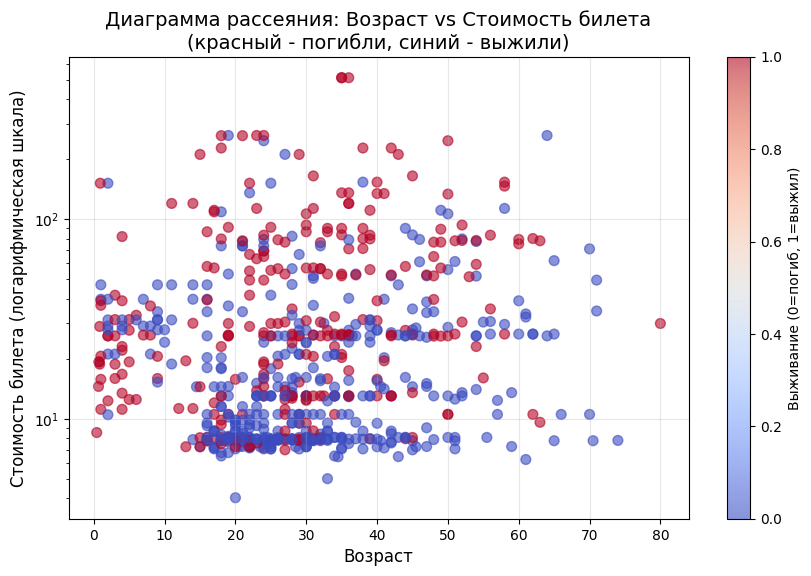

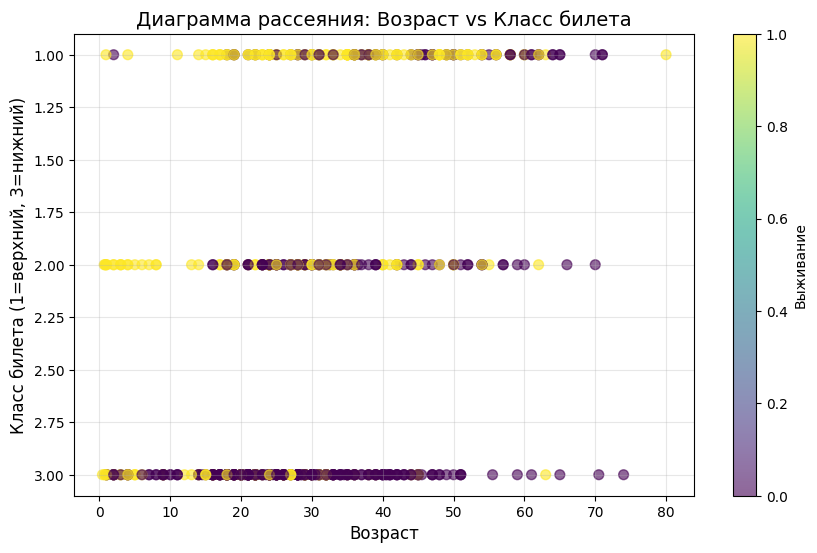

In [21]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(df['Age'], df['Fare'], 
                      c=df['Survived'], cmap='coolwarm', 
                      alpha=0.6, s=50)

plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Стоимость билета', fontsize=12)
plt.title('Диаграмма рассеяния: Возраст vs Стоимость билета\n(красный - погибли, синий - выжили)', fontsize=14)

plt.colorbar(scatter, label='Выживание (0=погиб, 1=выжил)')

plt.yscale('log')
plt.ylabel('Стоимость билета (логарифмическая шкала)')

plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))

scatter2 = plt.scatter(df['Age'], df['Pclass'], 
                       c=df['Survived'], cmap='viridis', 
                       alpha=0.6, s=50)

plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Класс билета (1=верхний, 3=нижний)', fontsize=12)
plt.title('Диаграмма рассеяния: Возраст vs Класс билета', fontsize=14)
plt.colorbar(scatter2, label='Выживание')

plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

#### 3. Столбчатая диаграмма: Постройте столбчатую диаграмму для сравнения выживаемости пассажиров в зависимости от пола или класса билета.

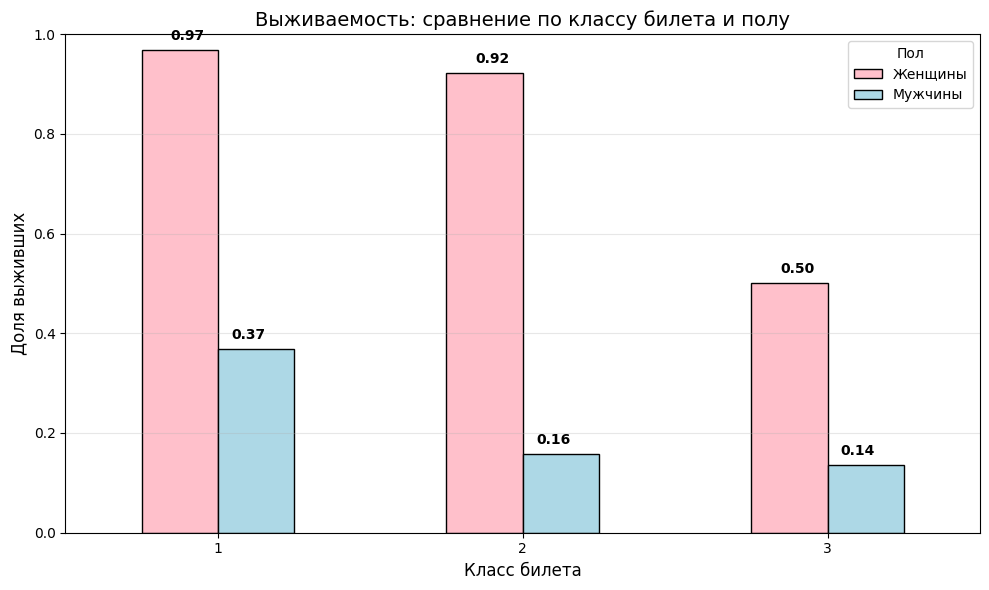

In [23]:
plt.figure(figsize=(10, 6))

survival_data = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

survival_data.plot(kind='bar', color=['pink', 'lightblue'], edgecolor='black', ax=plt.gca())

plt.xlabel('Класс билета', fontsize=12)
plt.ylabel('Доля выживших', fontsize=12)
plt.title('Выживаемость: сравнение по классу билета и полу', fontsize=14)
plt.legend(title='Пол', labels=['Женщины', 'Мужчины'])
plt.xticks(rotation=0)
plt.ylim(0, 1)

for i, (_, row) in enumerate(survival_data.iterrows()):
    for j, value in enumerate(row):
        if not pd.isna(value):
            plt.text(i + j*0.2 - 0.1, value + 0.02, f'{value:.2f}', 
                    ha='center', fontsize=10, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### 4. Боксплоты: Постройте boxplot (диаграмму размаха) для анализа распределения возраста пассажиров в зависимости от их выживаемости.

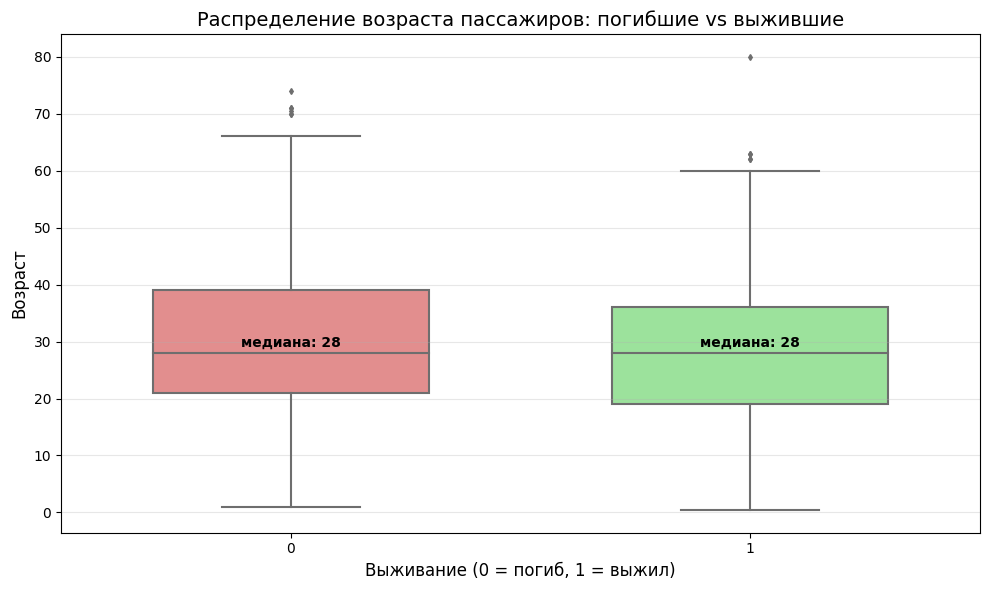

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Survived', y='Age', data=df, 
            palette={0: 'lightcoral', 1: 'lightgreen'},
            width=0.6, fliersize=3)

plt.xlabel('Выживание (0 = погиб, 1 = выжил)', fontsize=12)
plt.ylabel('Возраст', fontsize=12)
plt.title('Распределение возраста пассажиров: погибшие vs выжившие', fontsize=14)

# Добавляем медианные значения
medians = df.groupby('Survived')['Age'].median()
for i, median in enumerate(medians):
    plt.text(i, median + 1, f'медиана: {median:.0f}', 
             ha='center', fontsize=10, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### 5. Круговая диаграмма: Постройте круговую диаграмму для визуализации распределения пассажиров по полу или классу.

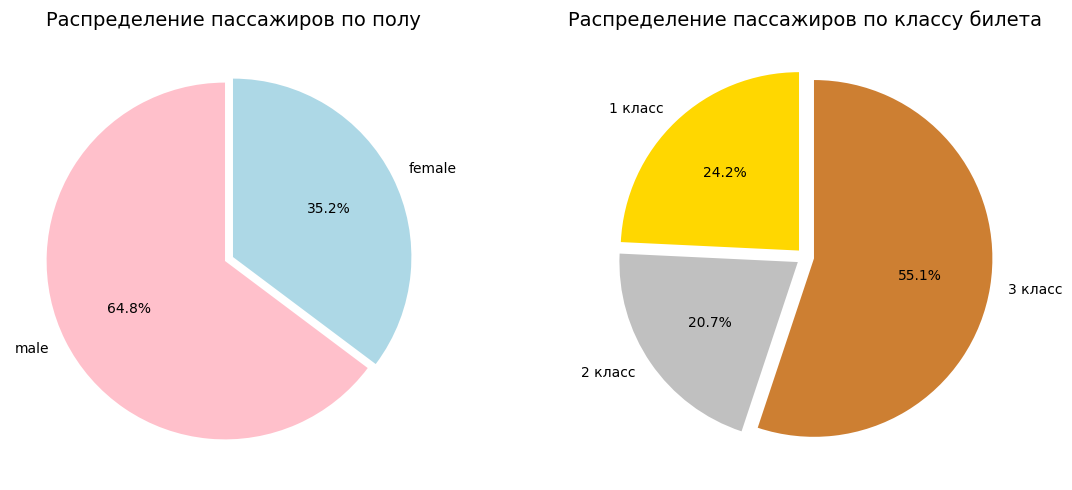

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
gender_counts = df['Sex'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
        colors=['pink', 'lightblue'], startangle=90, explode=(0.05, 0))
plt.title('Распределение пассажиров по полу', fontsize=14)

plt.subplot(1, 2, 2)
class_counts = df['Pclass'].value_counts().sort_index()
plt.pie(class_counts, labels=[f'{i} класс' for i in class_counts.index], 
        autopct='%1.1f%%', colors=['gold', 'silver', '#cd7f32'], 
        startangle=90, explode=(0.05, 0.05, 0.05))
plt.title('Распределение пассажиров по классу билета', fontsize=14)

plt.tight_layout()
plt.show()

#### 6. Дерево решений: На основе модели дерева решений, которую вы построили в предыдущем задании, визуализируйте структуру дерева. Опишите, какие выводы можно сделать на основе полученного дерева решений.

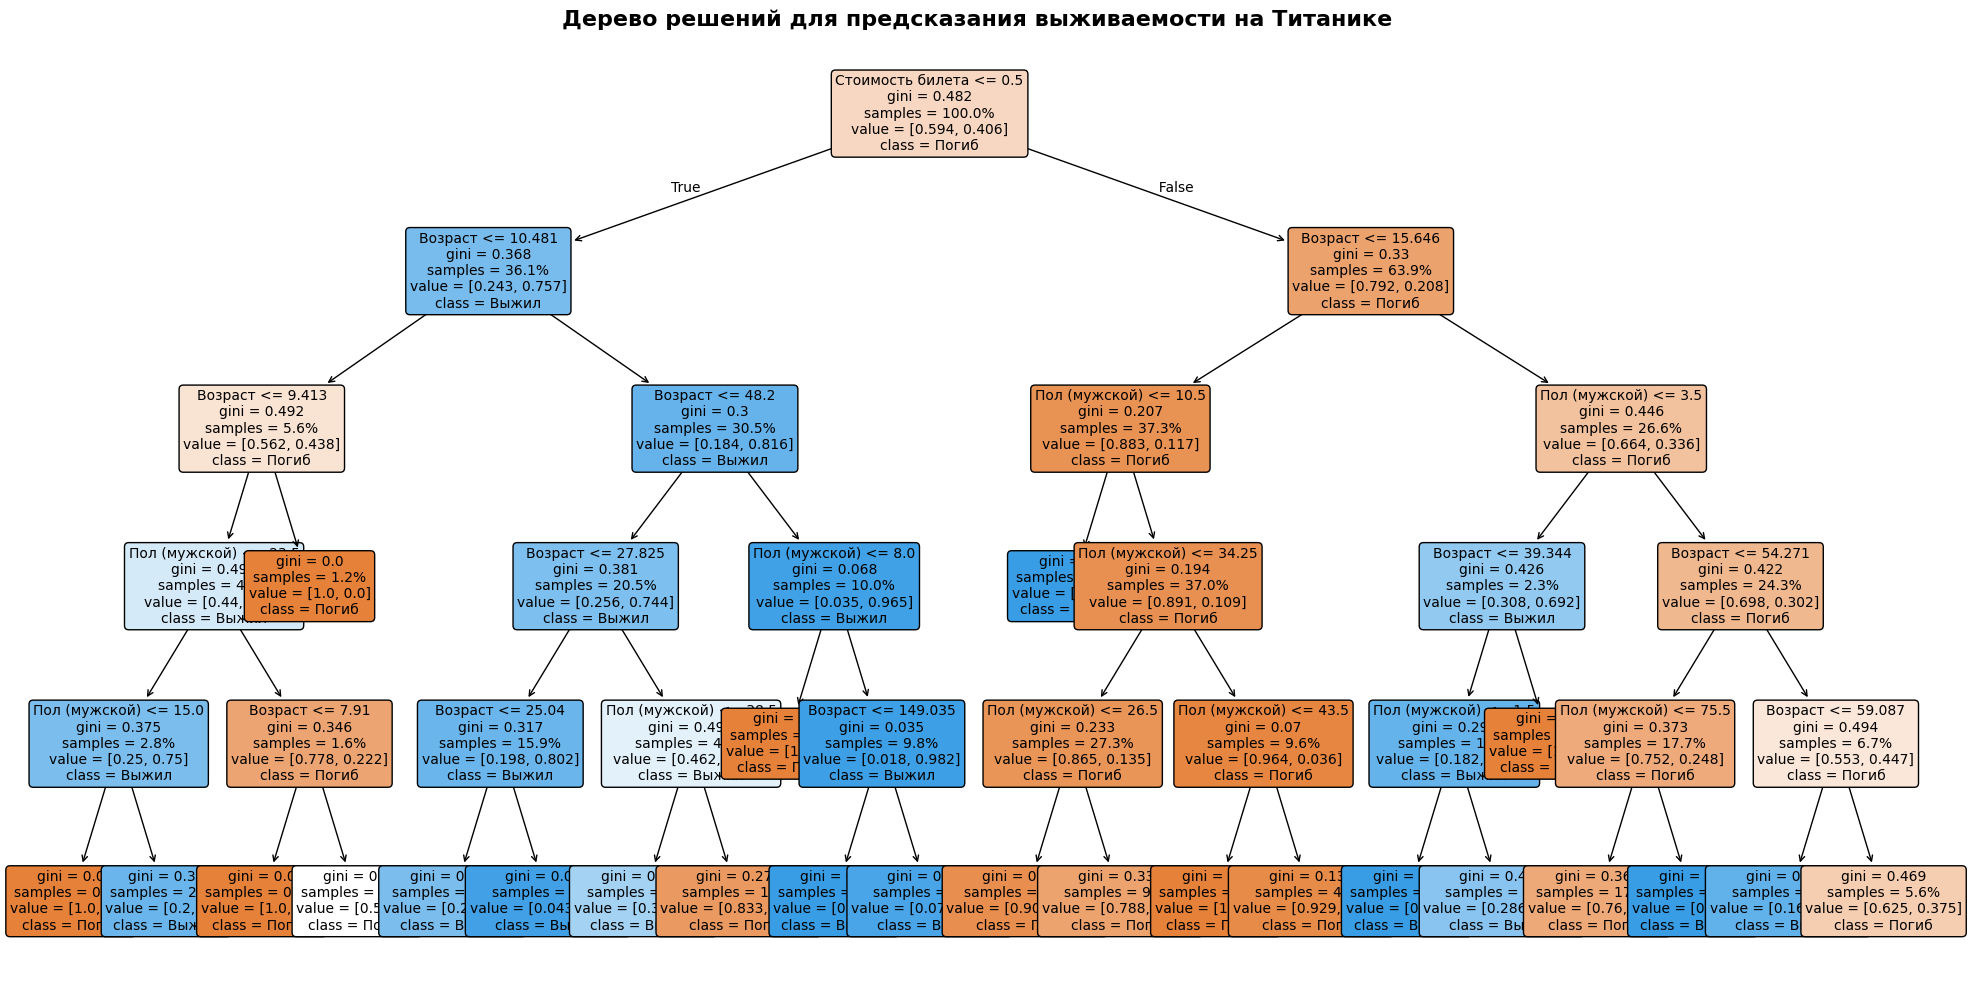

=== ПРАВИЛА ДЕРЕВА РЕШЕНИЙ ===

|--- Стоимость_билета <= 0.50
|   |--- Возраст <= 10.48
|   |   |--- Возраст <= 9.41
|   |   |   |--- Пол(мужской) <= 23.50
|   |   |   |   |--- Пол(мужской) <= 15.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Пол(мужской) >  15.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- Пол(мужской) >  23.50
|   |   |   |   |--- Возраст <= 7.91
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Возраст >  7.91
|   |   |   |   |   |--- class: 0
|   |   |--- Возраст >  9.41
|   |   |   |--- class: 0
|   |--- Возраст >  10.48
|   |   |--- Возраст <= 48.20
|   |   |   |--- Возраст <= 27.82
|   |   |   |   |--- Возраст <= 25.04
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Возраст >  25.04
|   |   |   |   |   |--- class: 1
|   |   |   |--- Возраст >  27.82
|   |   |   |   |--- Пол(мужской) <= 38.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Пол(мужской) >  38.50
|   |   |   |   |   |--- class: 0
|   |   |--- Возраст >  48.20
| 

In [28]:
from sklearn.tree import plot_tree
from sklearn.tree import export_text

plt.figure(figsize=(20, 10))
plot_tree(model, 
          feature_names=['Пол (мужской)', 'Возраст', 'Стоимость билета'],
          class_names=['Погиб', 'Выжил'],
          filled=True, 
          rounded=True,
          fontsize=10,
          proportion=True)
plt.title('Дерево решений для предсказания выживаемости на Титанике', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== ПРАВИЛА ДЕРЕВА РЕШЕНИЙ ===\n")
print(export_text(model, feature_names=['Пол(мужской)', 'Возраст', 'Стоимость_билета'], decimals=2))